***Step 1: Load & Explore the Data***

First, let’s load both CSV files and inspect their structure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
pbj_data = pd.read_csv('PBJ_Daily_Nurse_Staffing_Q2_2024.csv', encoding='latin1')  #used encoding='latin1' to avoid UnicodeDecodeError
nh_provider_info = pd.read_csv('NH_ProviderInfo_Feb2025.csv', encoding='latin1')


# Display basic info
print(pbj_data.head())  # Check the first few rows
print(nh_provider_info.head())  # Check the structure of the second dataset


C:\Users\CherRyY\AppData\Roaming\Python\Python39\site-packages\IPython\core\interactiveshell.py:3550: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


  PROVNUM                  PROVNAME          CITY STATE COUNTY_NAME  \
0   15009  BURNS NURSING HOME, INC.  RUSSELLVILLE    AL    Franklin   
1   15009  BURNS NURSING HOME, INC.  RUSSELLVILLE    AL    Franklin   
2   15009  BURNS NURSING HOME, INC.  RUSSELLVILLE    AL    Franklin   
3   15009  BURNS NURSING HOME, INC.  RUSSELLVILLE    AL    Franklin   
4   15009  BURNS NURSING HOME, INC.  RUSSELLVILLE    AL    Franklin   

   COUNTY_FIPS  CY_Qtr  WorkDate  MDScensus  Hrs_RNDON  ...  Hrs_LPN_ctr  \
0           59  2024Q2  20240401         51      10.77  ...          0.0   
1           59  2024Q2  20240402         52       8.43  ...          0.0   
2           59  2024Q2  20240403         53      11.13  ...          0.0   
3           59  2024Q2  20240404         52      12.27  ...          0.0   
4           59  2024Q2  20240405         52       4.95  ...          0.0   

   Hrs_CNA  Hrs_CNA_emp  Hrs_CNA_ctr  Hrs_NAtrn  Hrs_NAtrn_emp  Hrs_NAtrn_ctr  \
0   160.08       160.08          0.

***Step 2: Data Merging***

We need to merge the two datasets based on a common identifier, likely the Provider Number.

In [2]:
# Ensure column names are aligned
pbj_data.columns = pbj_data.columns.str.strip().str.lower()
nh_provider_info.columns = nh_provider_info.columns.str.strip().str.lower()

# Convert column names to lowercase for consistency
pbj_data.columns = pbj_data.columns.str.lower()
nh_provider_info.columns = nh_provider_info.columns.str.lower()

# Merge datasets on Provider Number (PROVNUM and CMS Certification Number)
merged_data = pd.merge(pbj_data, nh_provider_info, left_on='provnum', right_on='cms certification number (ccn)', how='left')

# Check first few rows
print(merged_data.head())


  provnum                  provname          city state_x county_name  \
0   15009  BURNS NURSING HOME, INC.  RUSSELLVILLE      AL    Franklin   
1   15009  BURNS NURSING HOME, INC.  RUSSELLVILLE      AL    Franklin   
2   15009  BURNS NURSING HOME, INC.  RUSSELLVILLE      AL    Franklin   
3   15009  BURNS NURSING HOME, INC.  RUSSELLVILLE      AL    Franklin   
4   15009  BURNS NURSING HOME, INC.  RUSSELLVILLE      AL    Franklin   

   county_fips  cy_qtr  workdate  mdscensus  hrs_rndon  ...  \
0           59  2024Q2  20240401         51      10.77  ...   
1           59  2024Q2  20240402         52       8.43  ...   
2           59  2024Q2  20240403         53      11.13  ...   
3           59  2024Q2  20240404         52      12.27  ...   
4           59  2024Q2  20240405         52       4.95  ...   

   number of citations from infection control inspections  number of fines  \
0                                                NaN                   NaN   
1                         

***Step 3: Data Cleaning & New Metrics***

In [3]:
# Fill missing contractor values with 0
merged_data[['hrs_lpn_ctr', 'hrs_cna_ctr']] = merged_data[['hrs_lpn_ctr', 'hrs_cna_ctr']].fillna(0)

# Calculate total staffing hours (RNs, LPNs, CNAs)
merged_data['total_staffing_hours'] = merged_data['hrs_rndon'] + merged_data['hrs_lpn'] + merged_data['hrs_cna']

# Calculate contractor percentage
merged_data['contractor_percentage'] = ((merged_data['hrs_lpn_ctr'] + merged_data['hrs_cna_ctr']) / merged_data['total_staffing_hours']) * 100

# Define "understaffed" (staffing hours < 70% of recommended)
merged_data['understaffed'] = merged_data['total_staffing_hours'] < (merged_data['mdscensus'] * 0.7)


***Step 4: Visualizations***

**1️. Bar Chart: Top 10 States with Highest Contractor Nurse Usage**

top 10 states with highest contractor usage percentage and sort in descending order of contractor percentage usage 


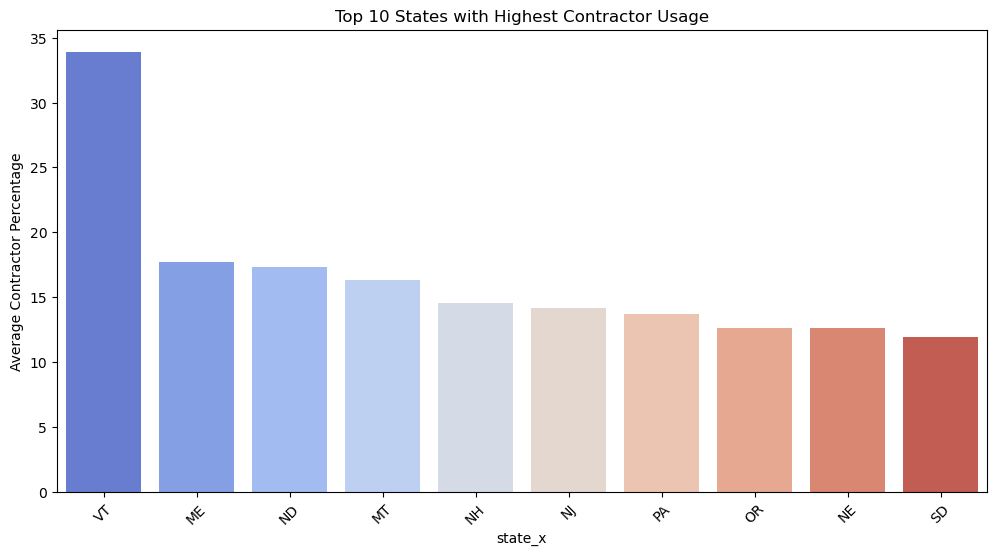

In [8]:

# Group by state and calculate average contractor percentage
top_states = merged_data.groupby('state_x')['contractor_percentage'].mean().sort_values(ascending=False).head(10) 
# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_states.index, y=top_states.values, palette='coolwarm')
plt.xlabel('state_x')
plt.ylabel('Average Contractor Percentage')
plt.title('Top 10 States with Highest Contractor Usage')
plt.xticks(rotation=45)
plt.show()


Insight: Clipboard Health should target states with high contractor usage.

**2. Bar Chart: Number of Understaffed Nursing Homes per State**

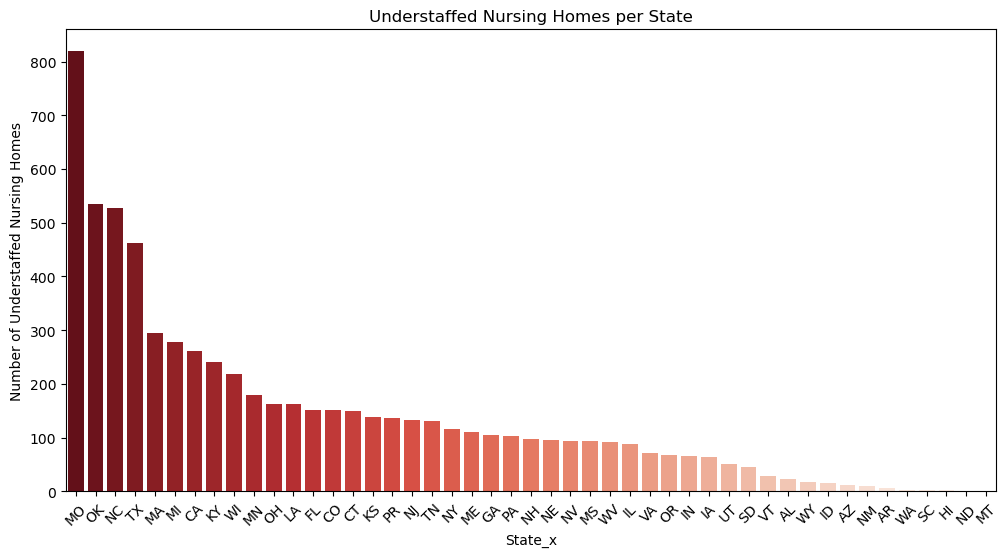

In [10]:
# Count understaffed nursing homes per state
understaffed_counts = merged_data[merged_data['understaffed']].groupby('state_x').size().sort_values(ascending=False) 

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=understaffed_counts.index, y=understaffed_counts.values, palette='Reds_r')
plt.xlabel('State_x')
plt.ylabel('Number of Understaffed Nursing Homes')
plt.title('Understaffed Nursing Homes per State')
plt.xticks(rotation=45)
plt.show()


Insight: Clipboard Health should prioritize outreach to states with high understaffing rates.

**3️ Pie Chart: Employee vs. Contractor Staffing**

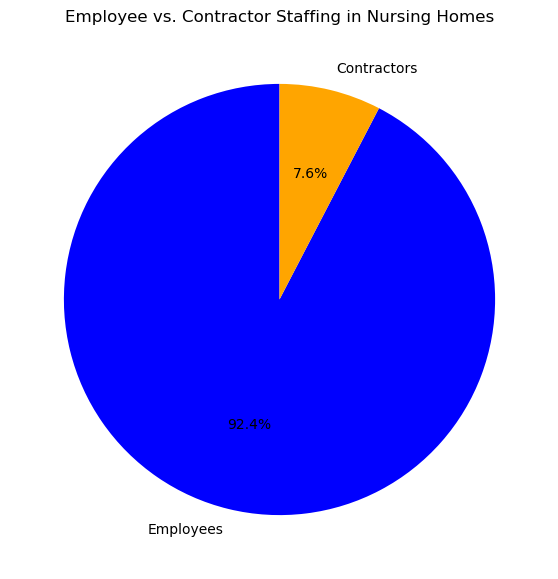

In [11]:
# Calculate total employee and contractor hours
total_employee_hours = merged_data['hrs_cna_emp'].sum() + merged_data['hrs_lpn_emp'].sum()
total_contractor_hours = merged_data['hrs_cna_ctr'].sum() + merged_data['hrs_lpn_ctr'].sum()

# Create pie chart
plt.figure(figsize=(7, 7))
plt.pie(
    [total_employee_hours, total_contractor_hours],
    labels=['Employees', 'Contractors'],
    autopct='%1.1f%%',
    colors=['blue', 'orange'],
    startangle=90
)
plt.title("Employee vs. Contractor Staffing in Nursing Homes")
plt.show()


Insight: If contractor usage is low, Clipboard Health can promote contract staffing solutions.

**4 Bar Chart: Nursing Homes with the Most Fines**

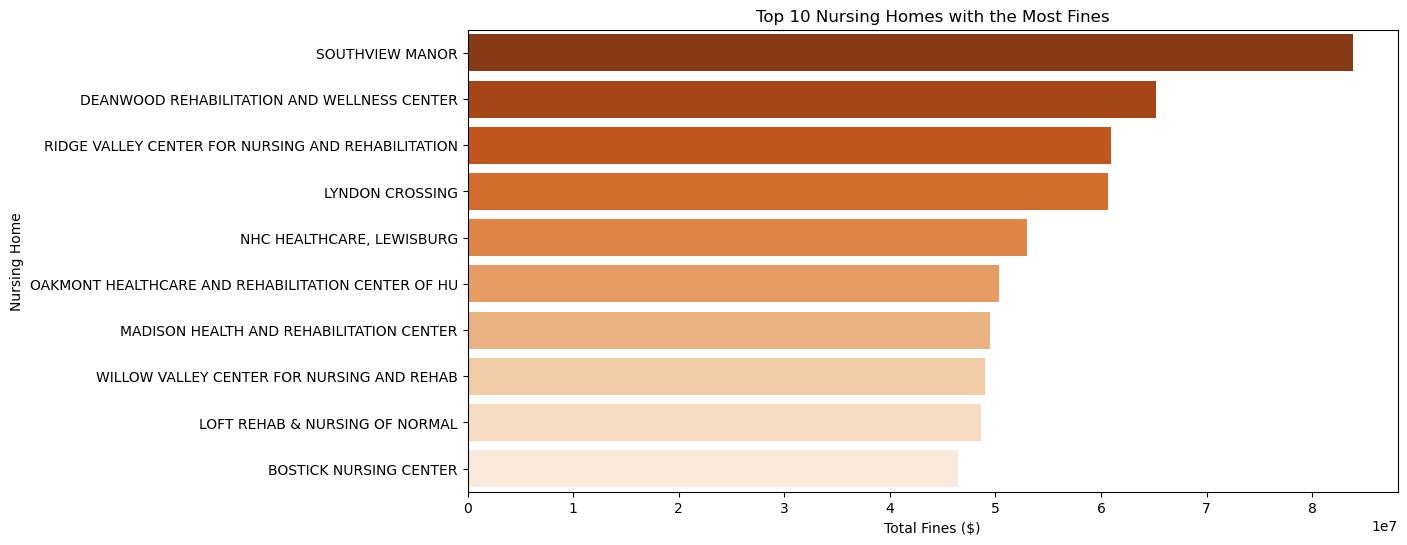

In [14]:
# Convert fine amounts to numeric
merged_data['total amount of fines in dollars'] = pd.to_numeric(merged_data['total amount of fines in dollars'], errors='coerce')

# Get top 10 nursing homes with highest fines
top_fines = merged_data.groupby('provname')['total amount of fines in dollars'].sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_fines.values, y=top_fines.index, palette='Oranges_r')
plt.xlabel('Total Fines ($)')
plt.ylabel('Nursing Home')
plt.title('Top 10 Nursing Homes with the Most Fines')
plt.show()


Insight: Homes with high fines may have staffing or compliance issues—potential customers for Clipboard Health.

---

***Key Recommendations for Clipboard Health***

Here’s how Clipboard Health can leverage staffing trends to maximize impact and business growth:



*1️ Target High Contractor-Usage States*

Some states already rely heavily on contract nurses, which means nursing homes in these areas are familiar with the model and more open to staffing partnerships. Clipboard Health can focus marketing and sales efforts here to convert existing demand into business opportunities with minimal resistance.

*2️ Support Understaffed Nursing Homes*

Nursing homes operating with 30% or more staffing shortages are at risk of non-compliance, poor patient care, and regulatory penalties. By proactively reaching out to these facilities, Clipboard Health can position itself as a reliable staffing solution to help them meet minimum requirements and improve patient outcomes.

*3️ Promote Contractor Staffing to Low-Usage States*

Some states still rely almost entirely on permanent staff instead of contract nurses, which may lead to burnout and long-term retention issues. Clipboard Health can introduce the benefits of flexible staffing, educating facilities on how contractors can reduce employee turnover and fill critical gaps without long hiring cycles.

*4️ Engage Nursing Homes with High Fines*

Nursing homes that have received large fines often face issues related to staffing shortages, patient safety, and regulatory compliance. Clipboard Health can position its services as a proactive solution to help these homes avoid future penalties by ensuring they maintain adequate staffing levels.